**IT Helpdesk Ticket Performance Analysis**

**IT Helpdesk Tickets**

IT Helpdesk Performance Analysis is a Python and Pandas project that analyzes IT support tickets to identify trends in ticket volume, resolution time, SLA breaches, team performance, and customer satisfaction. The project uses data analysis and visualization to generate insights and improve helpdesk efficiency.

1. Project Title

IT Helpdesk Ticket Performance Analysis Using Python

2. Project Overview

This project focuses on analysing IT helpdesk ticket data to understand the performance of an IT support system. The analysis examines ticket volume, ticket categories, priorities, SLA performance, response time, resolution time, support-team performance, agent performance, customer satisfaction, support channels, locations, and monthly trends.

The project was completed in two major stages:

Data Cleaning and Preprocessing
Exploratory Data Analysis and Visualization

Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Plotly were used for data manipulation, analysis, and visualization.

The main objective is to identify operational strengths and weaknesses in the helpdesk and provide insights that can help improve SLA compliance, resolution efficiency, and customer satisfaction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv(r"C:\Users\NAMITHA\Downloads\it_helpdesk_tickets_cleaned.csv")
df.head()

,ticket_id,created_date,resolved_date,category,priority,sla_target_hours,first_response_hours,resolution_time_hours,sla_breached,status,assigned_team,agent_name,location,channel,customer_satisfaction
0,INC100208,2025-01-01 12:06:25,2025-01-01 19:34:37,Access Management,Low,48,7.47,7.47,False,Closed,Security Team,L. Fernandes,Branch - New York,Email,5.0
1,INC100123,2025-01-01 13:36:24,2025-01-02 09:32:12,Printer,High,8,2.31,19.93,True,Resolved,Security Team,H. Osei,HQ - Dubai,Walk-in,4.0
2,INC100671,2025-01-01 13:38:35,2025-01-02 00:06:11,Software,High,8,3.20,10.46,True,Closed,Service Desk L1,E. Zhou,Branch - London,Self-Service Portal,1.0
3,INC100254,2025-01-01 16:58:07,2025-01-01 17:34:07,Email,High,8,0.60,0.60,False,Reopened,Network Ops,G. Petrov,HQ - Dubai,Self-Service Portal,NaN
4,INC101299,2025-01-01 17:52:03,2025-01-02 11:20:15,Printer,High,8,1.75,17.47,True,Resolved,App Support,H. Osei,HQ - Dubai,Self-Service Portal,4.0


In [4]:
df.dtypes

ticket_id                    str
created_date                 str
resolved_date                str
category                     str
priority                     str
sla_target_hours           int64
first_response_hours     float64
resolution_time_hours    float64
sla_breached                bool
status                       str
assigned_team                str
agent_name                   str
location                     str
channel                      str
customer_satisfaction    float64
dtype: object

In [5]:
# Convert datatypes

df["created_date"] = pd.to_datetime(df["created_date"])
df["resolved_date"] = pd.to_datetime(df["resolved_date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_id              3000 non-null   str           
 1   created_date           3000 non-null   datetime64[us]
 2   resolved_date          2862 non-null   datetime64[us]
 3   category               3000 non-null   str           
 4   priority               3000 non-null   str           
 5   sla_target_hours       3000 non-null   int64         
 6   first_response_hours   3000 non-null   float64       
 7   resolution_time_hours  3000 non-null   float64       
 8   sla_breached           3000 non-null   bool          
 9   status                 3000 non-null   str           
 10  assigned_team          3000 non-null   str           
 11  agent_name             3000 non-null   str           
 12  location               3000 non-null   str           
 13  channel       

**Analysing dataset**

In [34]:
# 1. Ticket Overview
# Total number of tickets
len(df)

3000

There are 3000 tickets are in total

In [35]:
# Open vs Closed vs Resolved vs Reopened tickets
status_counts = df["status"].value_counts()
print(status_counts)

status
Resolved    1981
Closed       542
Reopened     477
Name: count, dtype: int64


Most tickets are Resolved (1,981), while 477 tickets were Reopened.

In [36]:
# Number of Tickets by Category
category_counts = df["category"].value_counts()
print(category_counts)

category
Software               583
Hardware               491
Access Management      422
Application Support    400
Network                372
Email                  281
Printer                267
Security Incident      184
Name: count, dtype: int64


Software has the highest number of tickets, while Security Incident has the lowest.

priority
Low         1068
Medium      1024
High         688
Critical     220
Name: count, dtype: int64


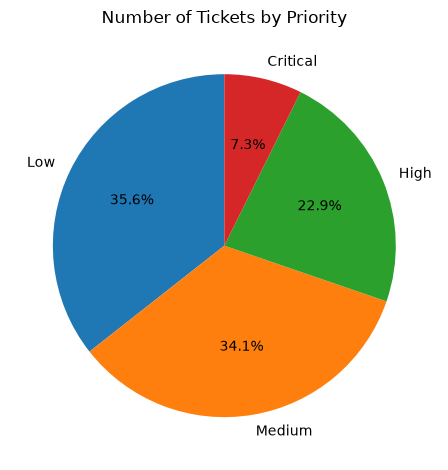

In [37]:
# Number of Tickets by Priority
priority_counts = df["priority"].value_counts()
print(priority_counts)
plt.pie(priority_counts.values, labels=priority_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Number of Tickets by Priority")
plt.tight_layout()
plt.show()

Low-priority tickets are the most common, while Critical tickets are the least common.

location
HQ - Dubai            1038
Remote                 884
Branch - London        470
Branch - Singapore     324
Branch - New York      284
Name: count, dtype: int64


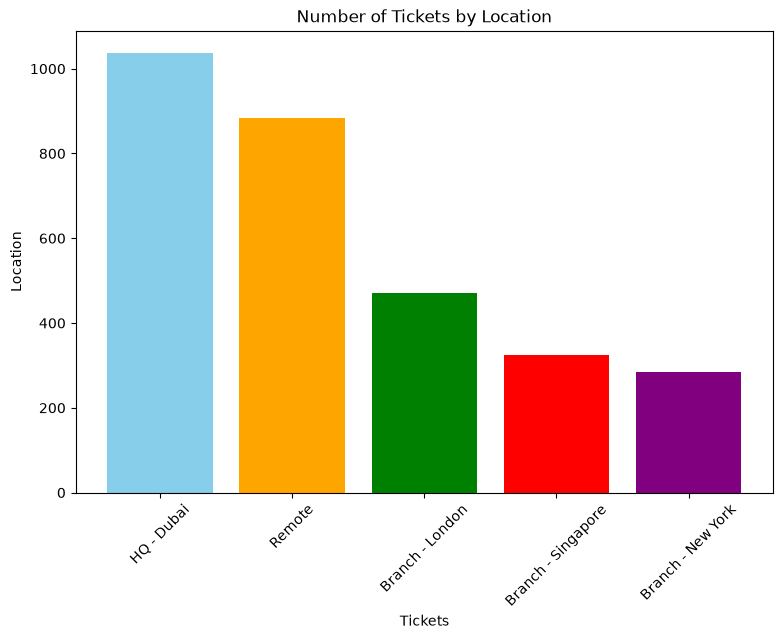

In [61]:
# Number of Tickets by Location

location_counts = df["location"].value_counts()
print(location_counts)
plt.figure(figsize=(9, 6))
plt.bar(location_counts.index,location_counts.values,color=["skyblue", "orange", "green", "red", "purple"])
plt.title("Number of Tickets by Location")
plt.xlabel("Tickets")
plt.ylabel("Location")
plt.xticks(rotation=45)
plt.show()

Dubai has the highest number of tickets, followed by Remote users.

In [39]:
# Number of Tickets by Support Channel
channel_counts = df["channel"].value_counts()
print(channel_counts)

channel
Email                  896
Self-Service Portal    890
Phone                  638
Chat                   422
Walk-in                154
Name: count, dtype: int64


Email is the most frequently used support channel, closely followed by the Self-Service Portal. Walk-in has the fewest tickets.

**Overall Ticket Overview**

The dataset contains 3,000 IT helpdesk tickets. Software is the most common ticket category, while Low priority tickets account for the largest priority group. HQ - Dubai has the highest ticket volume, and Email is the most frequently used support channel. Most tickets are Resolved, although 477 tickets have been Reopened.

In [40]:
# SLA Analysis

In [151]:
# SLA Breach Rate

# SLA breach count
sla_counts = df["sla_breached"].value_counts()
print(sla_counts)

# SLA breach percentage
sla_breach_rate = df["sla_breached"].mean() * 100
print("SLA Breach Rate:", round(sla_breach_rate, 2), "%")

sla_breached
False    2258
True      742
Name: count, dtype: int64
SLA Breach Rate: 24.73 %


priority
Critical    29.545455
Medium      24.707031
High        24.418605
Low         23.970037
Name: sla_breached, dtype: float64


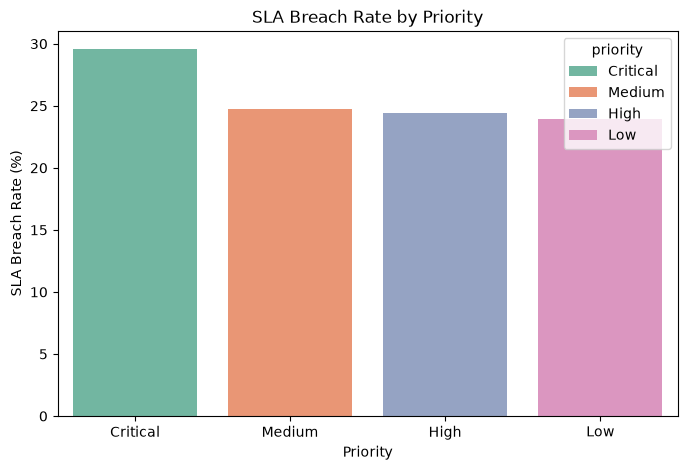

In [60]:
# SLA Breaches by Priority

import matplotlib.pyplot as plt
import seaborn as sns

sla_by_priority = (df.groupby("priority")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(sla_by_priority)

plt.figure(figsize=(8, 5))
sns.barplot(x=sla_by_priority.index, y=sla_by_priority.values, hue=sla_by_priority.index, palette="Set2", legend=True)
plt.title("SLA Breach Rate by Priority")
plt.xlabel("Priority")
plt.ylabel("SLA Breach Rate (%)")
plt.show()

Critical priority incidents has the greatest difficulty meeting SLA targets.

category
Email                  31.672598
Printer                27.340824
Access Management      24.881517
Hardware               24.847251
Network                24.193548
Software               22.984563
Security Incident      22.282609
Application Support    22.000000
Name: sla_breached, dtype: float64


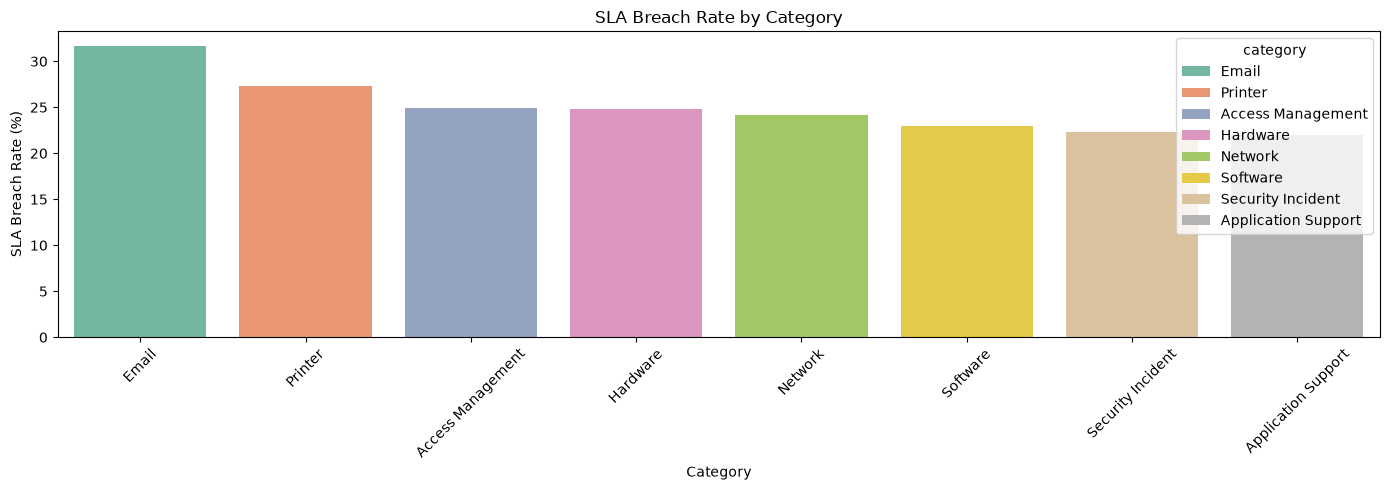

In [58]:
# SLA Breaches by Category

import seaborn as sns
import matplotlib.pyplot as plt

sla_by_category = (df.groupby("category")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(sla_by_category)

plt.figure(figsize=(14, 5))
sns.barplot(x=sla_by_category.index, y=sla_by_category.values, hue=sla_by_category.index, palette="Set2", legend=True)
plt.title("SLA Breach Rate by Category")
plt.xlabel("Category")
plt.ylabel("SLA Breach Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Email tickets have the highest SLA breach rate (31.67%), indicating potential delays in resolving email-related issues.

In [153]:
# Which categories have the most SLA violations?

print(df[df["sla_breached"]]["category"].value_counts())

category
Software               134
Hardware               122
Access Management      105
Network                 90
Email                   89
Application Support     88
Printer                 73
Security Incident       41
Name: count, dtype: int64


Software, Hardware, and Access Management categories have the most SLA violations.

assigned_team
Security Team      26.943942
Service Desk L1    25.786164
Desktop Support    25.154639
App Support        24.404762
Systems Admin      23.935091
Network Ops        21.926230
Name: sla_breached, dtype: float64


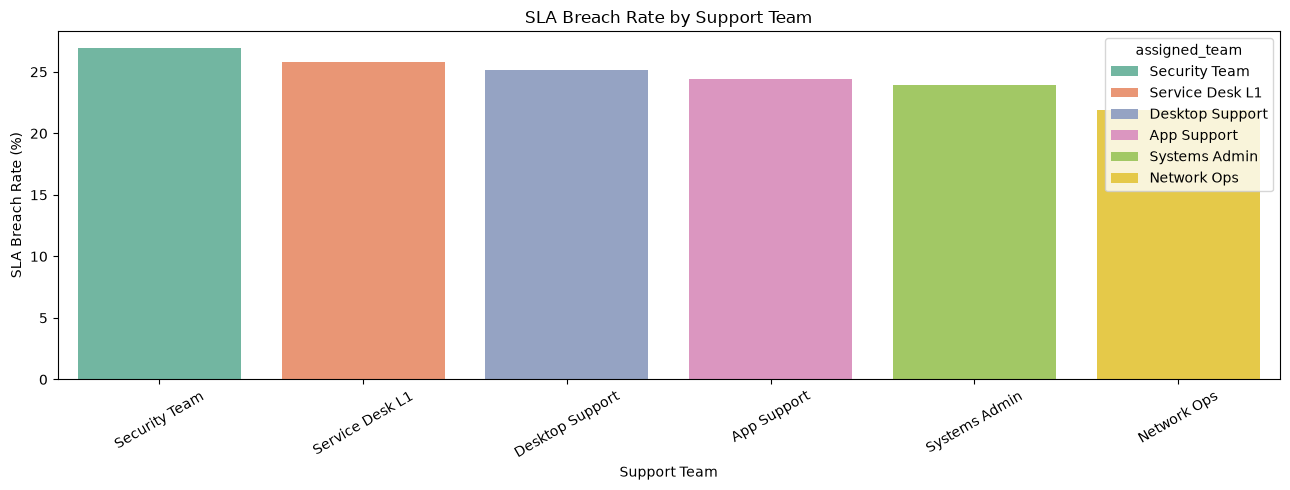

In [55]:
# SLA Breaches by Assigned Team

import seaborn as sns
import matplotlib.pyplot as plt

sla_by_team = (df.groupby("assigned_team")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(sla_by_team)

plt.figure(figsize=(13, 5))
sns.barplot(x=sla_by_team.index, y=sla_by_team.values, hue=sla_by_team.index, palette="Set2", legend=True)
plt.title("SLA Breach Rate by Support Team")
plt.xlabel("Support Team")
plt.ylabel("SLA Breach Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The Security Team has the highest SLA breach rate (26.94%), while Network Ops has the lowest (21.93%).

In [157]:
# SLA Breaches by Location

sla_by_location = (df.groupby("location")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(sla_by_location)

location
Remote                27.375566
Branch - Singapore    26.851852
Branch - London       26.382979
Branch - New York     23.943662
HQ - Dubai            21.290944
Name: sla_breached, dtype: float64


Remote tickets have the highest SLA breach rate (27.38%), while HQ - Dubai has the lowest (21.29%).

channel
Chat                   27.488152
Email                  25.111607
Self-Service Portal    24.831461
Walk-in                23.376623
Phone                  22.570533
Name: sla_breached, dtype: float64


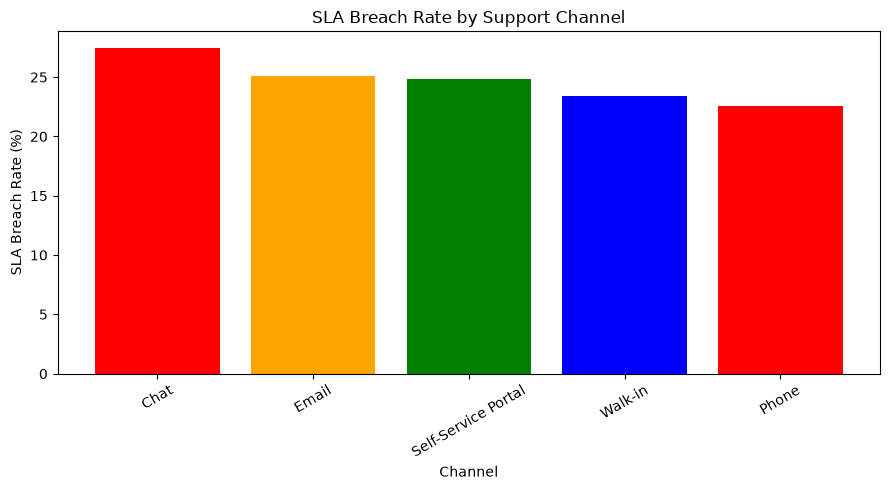

In [48]:
# SLA Breaches by Channel

sla_by_channel = (df.groupby("channel")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(sla_by_channel)

plt.figure(figsize=(9, 5))
colors = ["red", "orange", "green", "blue"]
plt.bar(sla_by_channel.index,sla_by_channel.values, color=colors[:len(sla_by_channel)]) 
plt.title("SLA Breach Rate by Support Channel")
plt.xlabel("Channel")
plt.ylabel("SLA Breach Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Chat has the highest SLA breach rate (27.49%), while Phone has the lowest (22.57%).

In [ ]:
# Response & Resolution Analysis

In [99]:
# Average First Response Time
avg_response = df["first_response_hours"].mean()
print("Average First Response Time:", round(avg_response, 2), "hours")

Average First Response Time: 6.34 hours


The helpdesk takes an average of 6.34 hours to provide the first response.

In [101]:
# Average Resolution Time

avg_resolution = df["resolution_time_hours"].mean()
print("Average Resolution Time:", round(avg_resolution, 2), "hours")

Average Resolution Time: 21.77 hours


Tickets take approximately 21.77 hours to resolve on average.

priority
Low         11.088165
Medium       5.564893
High         1.823997
Critical     0.988455
Name: first_response_hours, dtype: float64


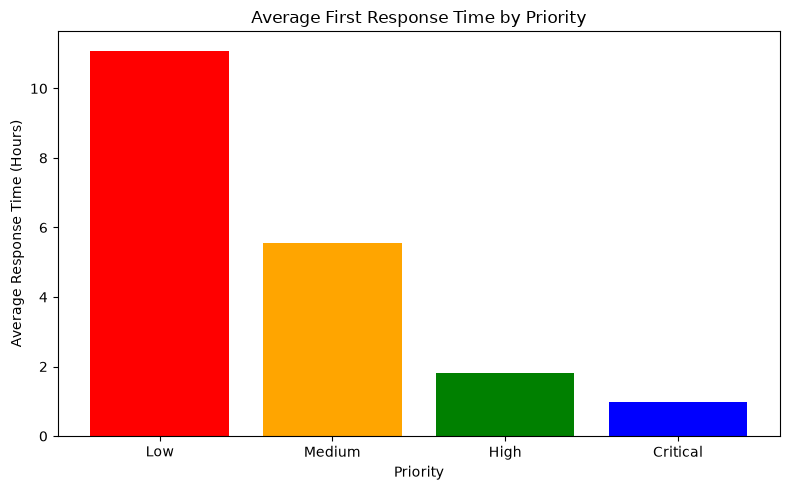

In [52]:
# Response Time by Priority

response_by_priority = (df.groupby("priority")["first_response_hours"].mean().sort_values(ascending=False))
print(response_by_priority)

plt.figure(figsize=(8, 5))
colors = ["red", "orange", "green", "blue"]
plt.bar(response_by_priority.index, response_by_priority.values, color=colors[:len(response_by_priority)])
plt.title("Average First Response Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Response Time (Hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Response time varies by priority, showing differences in how quickly different ticket types receive initial attention.

              Category  Average Resolution Time
0                Email                23.982562
1             Software                22.963173
2              Printer                22.293146
3             Hardware                21.536802
4              Network                21.466048
5    Security Incident                21.397554
6    Access Management                20.649431
7  Application Support                20.079000


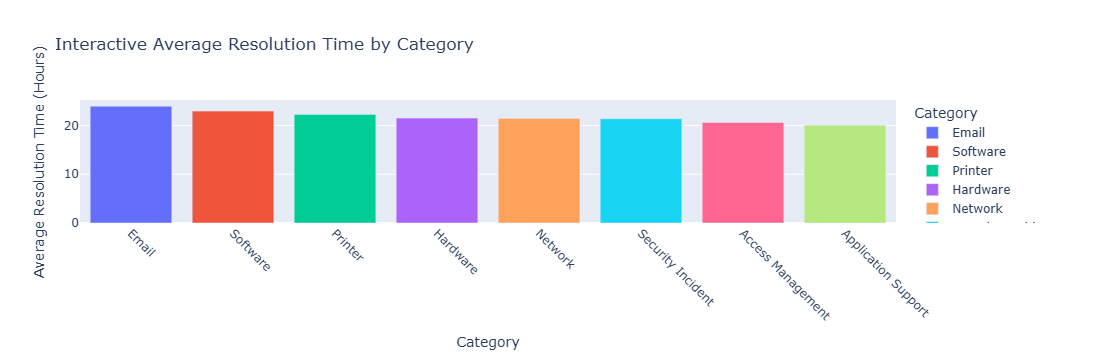

In [45]:
# Resolution Time by Category

import plotly.express as px

resolution_by_category = (df.groupby("category")["resolution_time_hours"].mean().sort_values(ascending=False).reset_index())
resolution_by_category.columns = ["Category", "Average Resolution Time"]
print(resolution_by_category)

figure = px.bar(resolution_by_category, x="Category", y="Average Resolution Time", color="Category", title="Interactive Average Resolution Time by Category",
hover_data=["Average Resolution Time"])

figure.update_layout(xaxis_title="Category",yaxis_title="Average Resolution Time (Hours)",xaxis_tickangle=45)

figure.show()

Email tickets take the longest to resolve (23.98 hours), while Application Support tickets are resolved fastest.

In [104]:
# Resolution Time by Support Team

resolution_by_team = (df.groupby("assigned_team")["resolution_time_hours"].mean().sort_values(ascending=False))
print(resolution_by_team)

assigned_team
Service Desk L1    23.180210
Desktop Support    22.215691
App Support        21.770020
Systems Admin      21.595396
Security Team      21.318228
Network Ops        20.660820
Name: resolution_time_hours, dtype: float64


Network Ops has the fastest average resolution time (20.66 hours), while Service Desk L1 takes the longest (23.18 hours).

In [105]:
# Resolution Time by Agent

resolution_by_agent = (df.groupby("agent_name")["resolution_time_hours"].mean().sort_values(ascending=False))
print(resolution_by_agent)

agent_name
F. Torres       23.905163
J. Kim          23.119646
D. Ahmed        22.824286
A. Khan         22.736481
G. Petrov       22.264084
L. Fernandes    22.234041
E. Zhou         21.987659
B. Silva        21.808226
H. Osei         20.617559
C. Novak        20.301076
K. Meyer        20.000507
I. Rossi        19.221048
Name: resolution_time_hours, dtype: float64


I. Rossi has the fastest average resolution time (19.22 hours), while F. Torres has the slowest (23.91 hours).

sla_target_hours         27.408000
resolution_time_hours    21.773883
dtype: float64


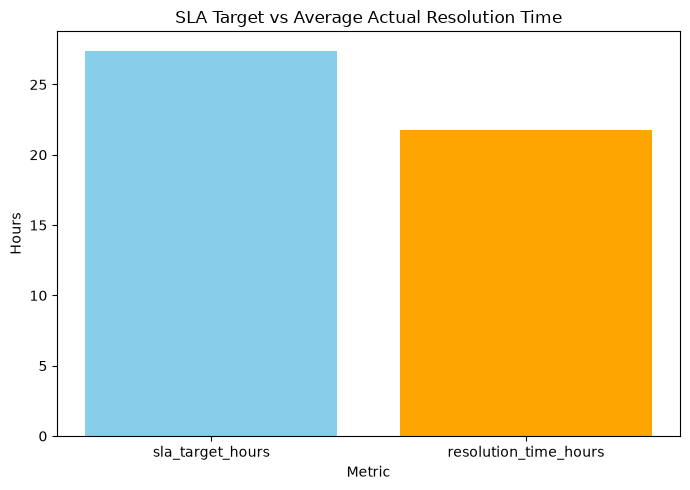

In [43]:
# SLA Target vs Actual Resolution Time

sla_comparison = df[["sla_target_hours", "resolution_time_hours"]].mean()
print(sla_comparison)

plt.figure(figsize=(7,5))
plt.bar(sla_comparison.index, sla_comparison.values, color=["skyblue", "orange"])
plt.title("SLA Target vs Average Actual Resolution Time")
plt.xlabel("Metric")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The average actual resolution time is below the SLA target, indicating that tickets are generally resolved within the overall target time.

                       sla_target_hours  first_response_hours  \
sla_target_hours               1.000000              0.662082   
first_response_hours           0.662082              1.000000   
resolution_time_hours          0.520404              0.403803   
customer_satisfaction         -0.009857             -0.034489   

                       resolution_time_hours  customer_satisfaction  
sla_target_hours                    0.520404              -0.009857  
first_response_hours                0.403803              -0.034489  
resolution_time_hours               1.000000              -0.274270  
customer_satisfaction              -0.274270               1.000000  


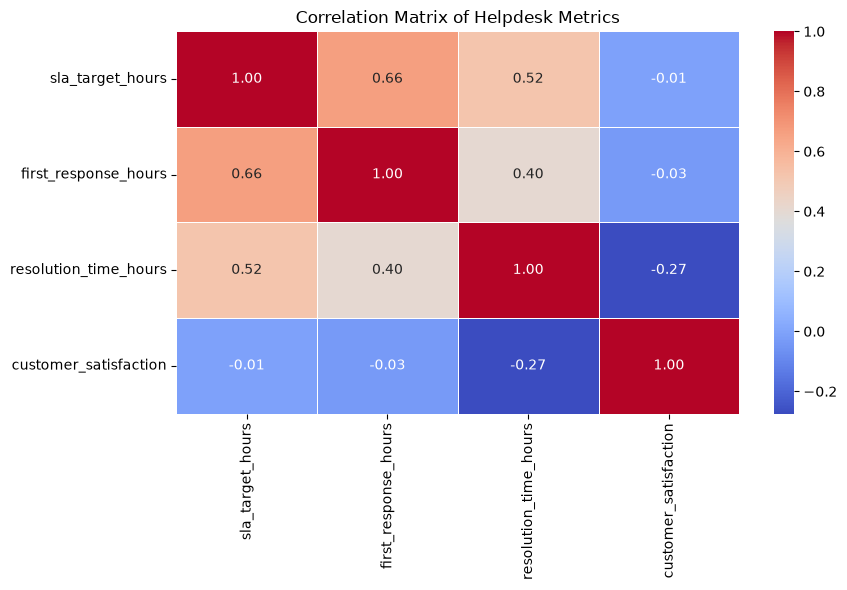

In [8]:
# Relationships between ticket performance metrics

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
correlation_data = df[["sla_target_hours", "first_response_hours", "resolution_time_hours", "customer_satisfaction"]]

# Create correlation matrix
correlation_matrix = correlation_data.corr()
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Helpdesk Metrics")

plt.tight_layout()
plt.show()

The correlation heatmap helps identify relationships between key helpdesk performance metrics. It is particularly useful for understanding how response time, resolution time, SLA targets, and customer satisfaction are related.

In [124]:
# Agent / Team Performance

In [125]:
# Tickets Handled by Each Agent

tickets_by_agent = (df["agent_name"].value_counts())
print(tickets_by_agent)

agent_name
D. Ahmed        273
B. Silva        265
G. Petrov       262
H. Osei         254
J. Kim          254
E. Zhou         252
C. Novak        251
I. Rossi        248
F. Torres       246
L. Fernandes    245
A. Khan         233
K. Meyer        217
Name: count, dtype: int64


D. Ahmed handled the most tickets (273), while K. Meyer handled the fewest (217).

In [126]:
# Average Resolution Time by Agent

agent_resolution = (df.groupby("agent_name")["resolution_time_hours"].mean().sort_values())
print(agent_resolution)

agent_name
I. Rossi        19.221048
K. Meyer        20.000507
C. Novak        20.301076
H. Osei         20.617559
B. Silva        21.808226
E. Zhou         21.987659
L. Fernandes    22.234041
G. Petrov       22.264084
A. Khan         22.736481
D. Ahmed        22.824286
J. Kim          23.119646
F. Torres       23.905163
Name: resolution_time_hours, dtype: float64


I. Rossi has the fastest average resolution time at 19.22 hours.

In [127]:
# Average First Response Time by Agent

agent_response = (df.groupby("agent_name")["first_response_hours"].mean().sort_values())
print(agent_response)

agent_name
K. Meyer        5.645899
I. Rossi        5.670645
C. Novak        6.001992
J. Kim          6.227244
A. Khan         6.263047
H. Osei         6.332598
B. Silva        6.439094
G. Petrov       6.543893
D. Ahmed        6.592564
E. Zhou         6.678968
L. Fernandes    6.758776
F. Torres       6.771870
Name: first_response_hours, dtype: float64


K. Meyer has the fastest average first response time at 5.65 hours.

In [128]:
# SLA Breach Percentage by Agent

agent_sla = (df.groupby("agent_name")["sla_breached"].mean().mul(100).sort_values(ascending=False))
print(agent_sla)

agent_name
A. Khan         29.613734
L. Fernandes    26.938776
G. Petrov       26.335878
C. Novak        25.896414
F. Torres       25.203252
E. Zhou         25.000000
B. Silva        24.528302
J. Kim          24.409449
H. Osei         22.834646
K. Meyer        22.580645
D. Ahmed        21.978022
I. Rossi        21.774194
Name: sla_breached, dtype: float64


I. Rossi has the lowest SLA breach rate (21.77%), while A. Khan has the highest (29.61%).

           Agent  Average Satisfaction
0       K. Meyer              4.127778
1       I. Rossi              4.091346
2         J. Kim              4.057778
3      G. Petrov              4.027027
4      F. Torres              3.990099
5       B. Silva              3.963470
6        A. Khan              3.958549
7       D. Ahmed              3.954545
8   L. Fernandes              3.936893
9        E. Zhou              3.929245
10      C. Novak              3.924171
11       H. Osei              3.896552


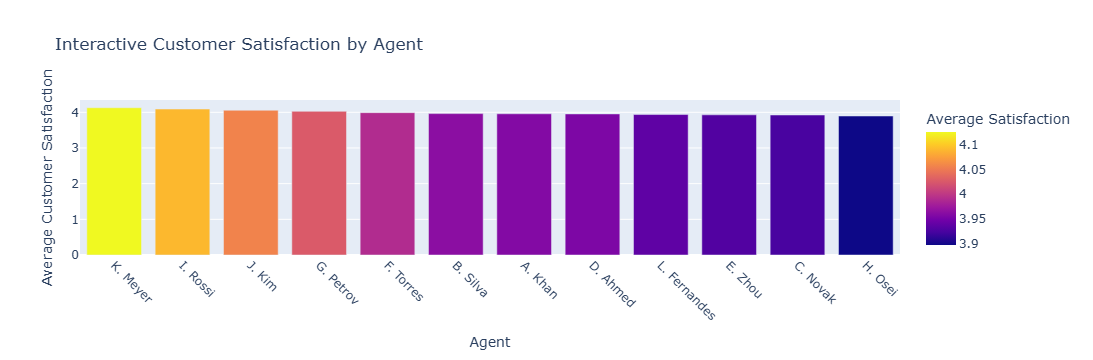

In [42]:
# Customer Satisfaction by Agent



import plotly.express as px
# Average satisfaction by agent
agent_satisfaction = (df.groupby("agent_name")["customer_satisfaction"].mean().sort_values(ascending=False).reset_index())
# Rename column
agent_satisfaction.columns = ["Agent","Average Satisfaction"]
print(agent_satisfaction)

# Interactive bar chart
figure = px.bar(agent_satisfaction,x="Agent",y="Average Satisfaction",title="Interactive Customer Satisfaction by Agent",color="Average Satisfaction",
hover_data=["Average Satisfaction"])

figure.update_layout(xaxis_title="Agent",yaxis_title="Average Customer Satisfaction",xaxis_tickangle=45)
figure.show()

K. Meyer has the highest average customer satisfaction score (4.13).

In [131]:
# Best-Performing Support Team
# A good way to compare teams is using resolution time, SLA breaches, and satisfaction.

team_performance = (df.groupby("assigned_team").agg(tickets=("ticket_id", "count"), avg_resolution=("resolution_time_hours", "mean"),
            avg_response=("first_response_hours", "mean"), sla_breach_rate=("sla_breached", "mean"), avg_satisfaction=("customer_satisfaction", "mean")))

team_performance["sla_breach_rate"] *= 100

print(team_performance.sort_values("avg_satisfaction", ascending=False))

                 tickets  avg_resolution  avg_response  sla_breach_rate  \
assigned_team                                                             
Service Desk L1      477       23.180210      6.566017        25.786164   
Security Team        553       21.318228      6.140759        26.943942   
Desktop Support      485       22.215691      6.235196        25.154639   
Network Ops          488       20.660820      6.418770        21.926230   
Systems Admin        493       21.595396      6.191805        23.935091   
App Support          504       21.770020      6.500317        24.404762   

                 avg_satisfaction  
assigned_team                      
Service Desk L1          4.032020  
Security Team            4.015487  
Desktop Support          4.007371  
Network Ops              3.982587  
Systems Admin            3.945882  
App Support              3.939675  


Network Ops is the strongest team for operational performance, particularly because it has the fastest resolution and lowest SLA breach rate.

In [132]:
# Customer Satisfaction

In [133]:
# Average Customer Satisfaction

avg_satisfaction = df["customer_satisfaction"].mean()
print("Average Customer Satisfaction:", round(avg_satisfaction, 2))

Average Customer Satisfaction: 3.99


Overall customer satisfaction is relatively high at approximately 3.99 out of 5.

In [134]:
# Satisfaction by Category

satisfaction_category = (df.groupby("category")["customer_satisfaction"].mean().sort_values(ascending=False))
print(satisfaction_category)

category
Security Incident      4.067568
Application Support    4.050000
Software               3.988024
Network                3.987055
Printer                3.976303
Hardware               3.966102
Access Management      3.951087
Email                  3.944206
Name: customer_satisfaction, dtype: float64


Customer satisfaction varies by ticket category, showing that some types of issues provide a better customer experience than others.

In [135]:
# Satisfaction by Priority

satisfaction_priority = (df.groupby("priority")["customer_satisfaction"].mean())
print(satisfaction_priority)

priority
Critical    4.034091
High        3.957371
Low         3.964951
Medium      4.019518
Name: customer_satisfaction, dtype: float64


Satisfaction differs across priority levels, indicating that the handling of urgent and non-urgent tickets affects customer experience.

In [136]:
# Satisfaction by Agent

print(df.groupby("agent_name")["customer_satisfaction"].mean().sort_values(ascending=False))

agent_name
K. Meyer        4.127778
I. Rossi        4.091346
J. Kim          4.057778
G. Petrov       4.027027
F. Torres       3.990099
B. Silva        3.963470
A. Khan         3.958549
D. Ahmed        3.954545
L. Fernandes    3.936893
E. Zhou         3.929245
C. Novak        3.924171
H. Osei         3.896552
Name: customer_satisfaction, dtype: float64


K. Meyer has the highest agent satisfaction score (4.13).

In [137]:
# Satisfaction by Team

print(df.groupby("assigned_team")["customer_satisfaction"].mean().sort_values(ascending=False))

assigned_team
Service Desk L1    4.032020
Security Team      4.015487
Desktop Support    4.007371
Network Ops        3.982587
Systems Admin      3.945882
App Support        3.939675
Name: customer_satisfaction, dtype: float64


ervice Desk L1 has the highest team satisfaction score (4.03).

In [138]:
# Satisfaction by Channel

satisfaction_channel = (df.groupby("channel")["customer_satisfaction"].mean().sort_values(ascending=False))
print(satisfaction_channel)

channel
Self-Service Portal    4.036145
Phone                  3.996296
Email                  3.991989
Walk-in                3.897810
Chat                   3.891429
Name: customer_satisfaction, dtype: float64


The Self-Service Portal has the highest customer satisfaction (4.04), while Chat has the lowest (3.89).

                       resolution_time_hours  customer_satisfaction
resolution_time_hours                1.00000               -0.27427
customer_satisfaction               -0.27427                1.00000


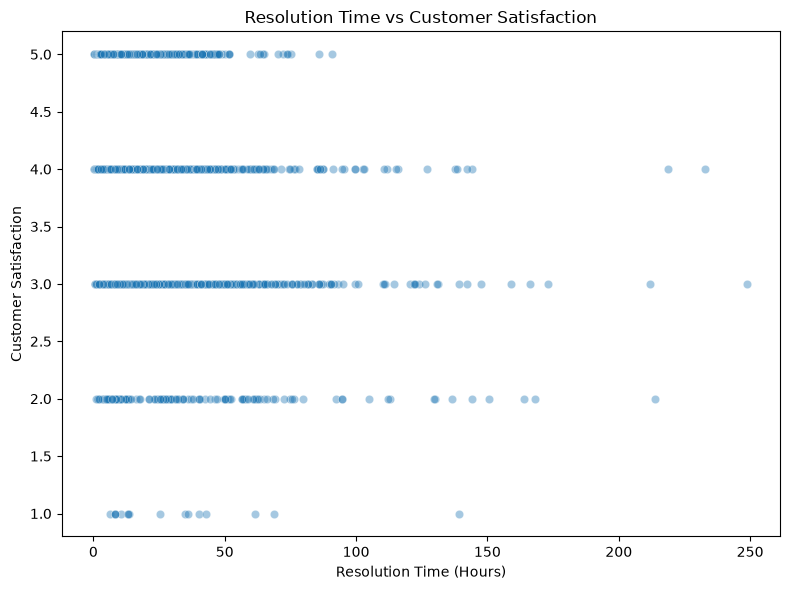

In [32]:
# Resolution Time vs Customer Satisfaction

import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[["resolution_time_hours", "customer_satisfaction"]].corr()
print(correlation)

# Scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,x="resolution_time_hours",y="customer_satisfaction",alpha=0.4)

plt.title("Resolution Time vs Customer Satisfaction")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Customer Satisfaction")
plt.tight_layout()
plt.show()

There is a moderate negative relationship between resolution time and satisfaction, meaning longer resolution times tend to be associated with lower customer satisfaction.

In [140]:
# SLA Breaches vs Satisfaction

sla_satisfaction = (df.groupby("sla_breached")["customer_satisfaction"].mean())
print(sla_satisfaction)

sla_breached
False    4.214846
True     3.272131
Name: customer_satisfaction, dtype: float64


SLA-breached tickets have substantially lower satisfaction, showing that meeting SLA targets is strongly associated with better customer experience.

In [141]:
# Time-Based Analysis

   created_date  ticket_volume
0    2025-01-31            258
1    2025-02-28            253
2    2025-03-31            248
3    2025-04-30            261
4    2025-05-31            267
5    2025-06-30            249
6    2025-07-31            245
7    2025-08-31            253
8    2025-09-30            255
9    2025-10-31            241
10   2025-11-30            245
11   2025-12-31            225


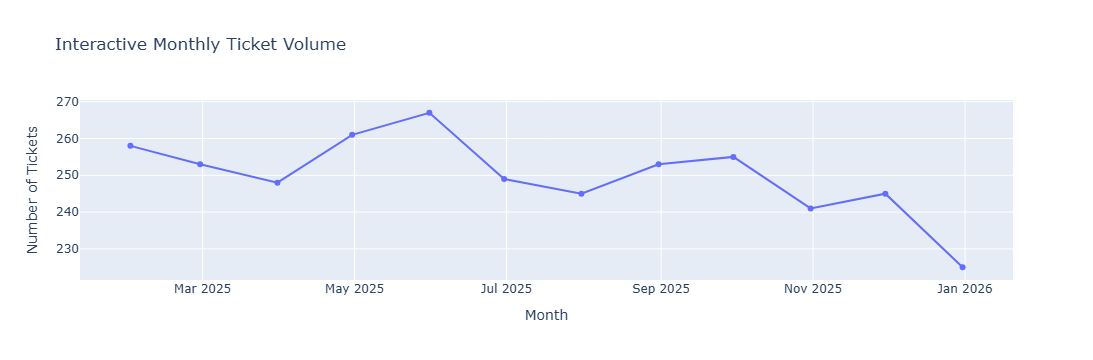

In [39]:
# Tickets Created per Month

import plotly.express as px

monthly_tickets = (df.set_index("created_date").resample("ME").size().reset_index(name="ticket_volume"))
print(monthly_tickets)

figure = px.line(monthly_tickets,x="created_date",y="ticket_volume",markers=True,title="Interactive Monthly Ticket Volume")

figure.update_layout(xaxis_title="Month", yaxis_title="Number of Tickets")

figure.show()

Ticket volume varies throughout the year, with May having the highest volume (267 tickets) and December the lowest (225).

        Month  SLA_Breach_Rate
0  2025-01-31        27.906977
1  2025-02-28        24.110672
2  2025-03-31        25.806452
3  2025-04-30        29.118774
4  2025-05-31        25.093633
5  2025-06-30        26.907631
6  2025-07-31        24.081633
7  2025-08-31        20.553360
8  2025-09-30        20.000000
9  2025-10-31        24.481328
10 2025-11-30        24.081633
11 2025-12-31        24.444444


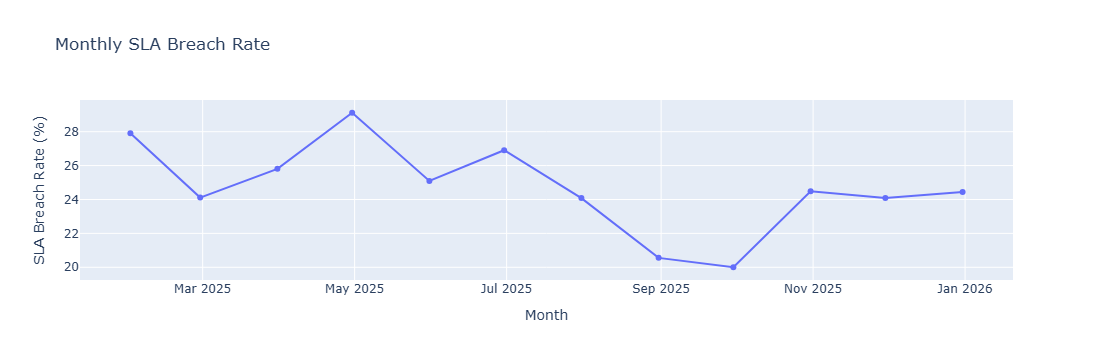

In [38]:
# Monthly SLA Breach Rate

import plotly.express as px

# Monthly SLA Breach Rate
monthly_sla = (df.set_index("created_date")["sla_breached"].resample("ME").mean().mul(100).reset_index())
monthly_sla.columns = ["Month", "SLA_Breach_Rate"]
print(monthly_sla)

# Interactive line chart
figure = px.line(monthly_sla, x="Month", y="SLA_Breach_Rate", markers=True, title="Monthly SLA Breach Rate")

figure.update_layout(xaxis_title="Month",yaxis_title="SLA Breach Rate (%)")

figure.show()

The interactive chart shows how the SLA breach rate changes month by month and helps identify periods with higher or lower SLA performance.
April has the highest SLA breach rate (29.12%), while September has the lowest (20.00%).

In [163]:
# Identify High Ticket Volume Periods

monthly_tickets = monthly_tickets.sort_values(ascending=False)

print("Highest Ticket Volume Months:")
print(monthly_tickets.head())

Highest Ticket Volume Months:
created_date
2025-05-31    267
2025-04-30    261
2025-01-31    258
2025-09-30    255
2025-08-31    253
dtype: int64


May has the highest monthly ticket volume, but the increase is not extreme enough to clearly classify it as an unusual outlier based on the standard-deviation method.

                     ticket_volume  avg_response_time  avg_resolution_time  \
channel                                                                      
Chat                           422           6.688104            24.402322   
Email                          896           6.498929            22.723471   
Phone                          638           6.070643            20.198339   
Self-Service Portal            890           6.250213            20.930921   
Walk-in                        154           6.050649            20.445325   

                     sla_breach_rate  avg_satisfaction  
channel                                                 
Chat                       27.488152          3.891429  
Email                      25.111607          3.991989  
Phone                      22.570533          3.996296  
Self-Service Portal        24.831461          4.036145  
Walk-in                    23.376623          3.897810  


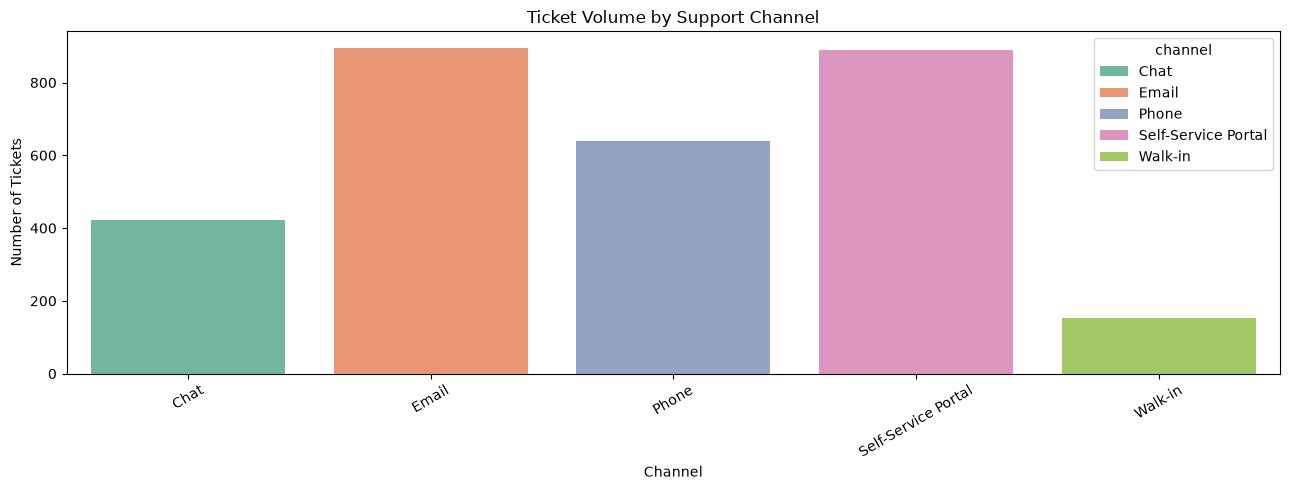

In [28]:
# 7. Channel Analysis

channel_analysis = (df.groupby("channel").agg(ticket_volume=("ticket_id", "count"), avg_response_time=("first_response_hours", "mean"), 
 avg_resolution_time=("resolution_time_hours", "mean"), sla_breach_rate=("sla_breached", "mean"), avg_satisfaction=("customer_satisfaction", "mean")))

channel_analysis["sla_breach_rate"] *= 100
print(channel_analysis)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))

sns.barplot(x=channel_analysis.index, y=channel_analysis["ticket_volume"], hue=channel_analysis.index, palette="Set2", legend=True)

plt.title("Ticket Volume by Support Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


Email has the highest ticket volume, while Phone has the best operational performance with the lowest SLA breach rate and fast resolution. The Self-Service Portal provides the highest customer satisfaction. Chat performs weakest overall, with the longest resolution time and highest SLA breach rate.

                    ticket_volume  avg_resolution_time  sla_breach_rate  \
location                                                                  
Branch - London               470            21.040277        26.382979   
Branch - New York             284            20.512958        23.943662   
Branch - Singapore            324            24.680525        26.851852   
HQ - Dubai                   1038            20.907977        21.290944   
Remote                        884            22.520441        27.375566   

                    avg_satisfaction  
location                              
Branch - London             3.981865  
Branch - New York           4.049793  
Branch - Singapore          3.985507  
HQ - Dubai                  3.985040  
Remote                      3.972037  


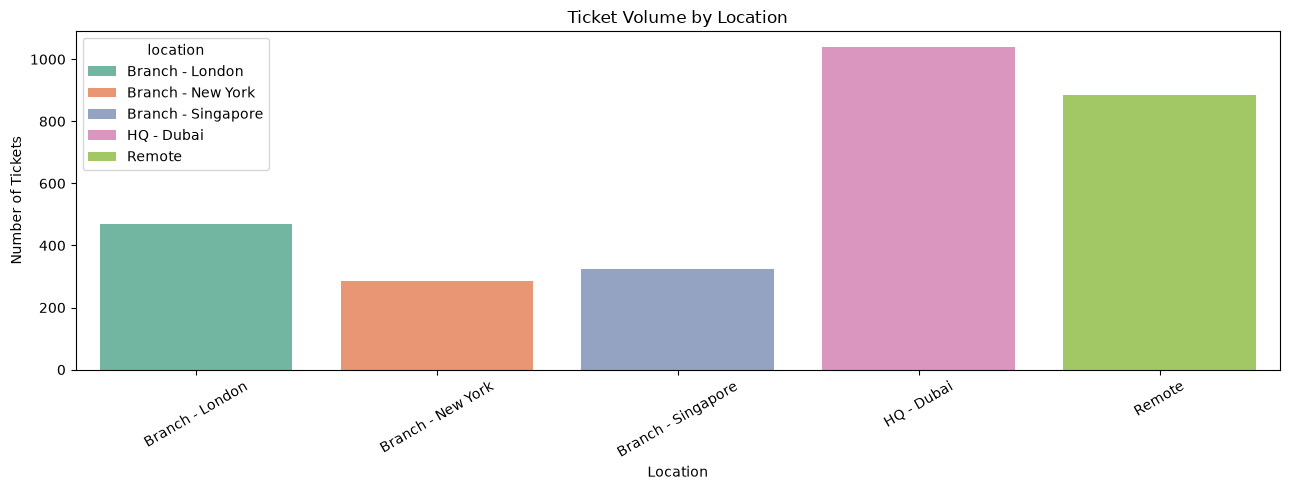

In [29]:
# 8.Location Analysis

location_analysis = (df.groupby("location").agg(ticket_volume=("ticket_id", "count"),avg_resolution_time=("resolution_time_hours", "mean"),
                                                sla_breach_rate=("sla_breached", "mean"),avg_satisfaction=("customer_satisfaction", "mean")))

location_analysis["sla_breach_rate"] *= 100
print(location_analysis)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))
sns.barplot(x=location_analysis.index, y=location_analysis["ticket_volume"], hue=location_analysis.index, palette="Set2", legend=True)

plt.title("Ticket Volume by Location")
plt.xlabel("Location")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

HQ - Dubai has the highest ticket volume and the lowest SLA breach rate. Singapore has the longest resolution time, while New York has the highest customer satisfaction. Remote users have the highest SLA breach rate and may require additional support attention.

1. Overall Ticket Analysis
   There are 3,000 tickets in the dataset.
   Most tickets were Resolved, with 1,981 tickets. However, 477 tickets were Reopened, which is an important operational point because reopened tickets can indicate that the original solution did not completely address the customer's issue.
   The helpdesk is successfully resolving a large majority of tickets, but the number of reopened tickets suggests that there is still room to improve first-time resolution and solution quality.

2. Ticket Category Analysis
   Software generated the highest number of tickets, with 583 tickets, while Security Incident had the lowest, with 184 tickets.
   Software-related problems represent the largest source of helpdesk workload. Therefore, software troubleshooting, user training, documentation, and self-service solutions could potentially reduce the number of recurring software tickets.

3. Priority Analysis
   Low-priority tickets are the largest group, while Critical tickets are the smallest.
   Although Critical tickets represent a relatively small portion of the total workload, they require faster attention because their SLA targets are more demanding.

4. Location Analysis
   HQ - Dubai has the highest ticket volume, followed by Remote users.
   The high volume from HQ - Dubai is expected to require significant helpdesk resources. However, Remote users are particularly important because their SLA breach rate is higher.

5. Support Channel Analysis
    Email is the most frequently used support channel, closely followed by the Self-Service Portal. Walk-in has the lowest volume.
    Although Email has the highest volume, the Self-Service Portal has the highest customer satisfaction, suggesting that encouraging users to use self-service could be beneficial.

6. SLA Analysis
    SLA performance is one of the most important parts of this project.
    Out of 3,000 tickets:
        2,258 tickets did not breach SLA
        742 tickets breached SLA
        Overall SLA breach rate = 24.73%
    This means approximately one-quarter of the tickets did not meet their defined SLA target.
    Although the average resolution time is below the overall average SLA target, SLA performance is still an important weakness because 24.73% of tickets breached SLA.

7. SLA Breach by Priority
    Critical tickets have the highest SLA breach rate at 29.55%.
    Critical incidents are the most difficult to resolve within their SLA targets. Since these tickets have high business importance, the helpdesk should give them additional monitoring and escalation support.
    
8. SLA Breach by Category
    Email has the highest SLA breach rate at 31.67%.
    Interestingly, Software has the highest number of total SLA violations (134) because it also has the highest ticket volume. Hardware has 122 violations and Access Management has 105.
    This shows why both breach rate and number of breaches are useful:
        Email has the highest percentage of tickets breaching SLA.
        Software has the highest number of SLA violations.

9. SLA Breach by Support Team
   Security Team has the highest SLA breach rate, while Network Ops has the lowest.
   Network Ops demonstrates relatively strong SLA performance. Security Team may need additional investigation to determine whether ticket complexity, workload, or resource allocation contributes to its higher breach rate.

10. SLA Breach by Location
    Remote users have the highest SLA breach rate at 27.38%, while HQ - Dubai has the lowest at 21.29%.
    Remote support appears to be an important area for improvement. Remote users may experience additional difficulties related to connectivity, access, or communication.

11. SLA Breach by Channel
    Chat has the highest SLA breach rate, while Phone has the lowest.
    Chat requires attention because it combines a relatively high SLA breach rate with the lowest customer satisfaction.

12. Response Time Analysis
    The average first response time is: 6.34 hours
    The average resolution time is: 21.77 hours
    The results show a clear priority-based response pattern. Critical tickets receive attention much faster than Low-priority tickets.
    This indicates that the helpdesk is prioritizing urgent incidents appropriately.
    
13. Resolution Time by Category
    Email has the longest average resolution time at 23.98 hours, while Application Support is the fastest at 20.08 hours.
    Email issues are a major concern because Email has:
        Highest ticket volume
        Highest SLA breach rate
        Longest average resolution time among categories
    Therefore, Email-related incidents should be one of the primary improvement areas.

14. Resolution Time by Support Team
    Network Ops has the fastest average resolution time, while Service Desk L1 has the longest.

15. Agent Performance
    The analysis also compared average resolution time among agents.
        The fastest average resolution was achieved by: I. Rossi – 19.22 hours
        The slowest average resolution was: F. Torres – 23.91 hours
    The project therefore provides a way to identify differences in individual agent performance.
    However, these figures should be interpreted carefully because agents may receive different types, priorities, and volumes of tickets.
 
16. SLA Target vs Actual Resolution
        The average SLA target is: 27.41 hours
        The average actual resolution time is: 21.77 hours
    This means the overall average resolution time is approximately 5.63 hours below the average SLA target.
    At an overall level, the helpdesk is resolving tickets faster than the average SLA target. However, this does not mean every ticket meets its SLA, as demonstrated by the 24.73% overall breach rate.

17. Customer Satisfaction Analysis
        The average customer satisfaction score is: 3.99 / 5
    There were 2,523 recorded satisfaction responses.
    This represents generally positive customer feedback, but there is still room for improvement.  

18. Customer Satisfaction by Team
    Service Desk L1 has the highest team satisfaction score at 4.03.

19. Customer Satisfaction by Channel
    The Self-Service Portal has the highest satisfaction score, while Chat has the lowest.
    The Self-Service Portal appears to be an effective support channel from a customer satisfaction perspective.
    Chat, on the other hand, should be investigated because it has:
        Lowest satisfaction, Highest SLA breach rate, Longest average resolution time

20. Resolution Time vs Customer Satisfaction
    The correlation between resolution time and customer satisfaction is: -0.27427
    This indicates a negative relationship between resolution time and satisfaction.
    In simple terms: As resolution time increases, customer satisfaction tends to decrease.
    This is an important business insight because it demonstrates that improving resolution speed can potentially improve customer experience.
    The relationship is not extremely strong, so resolution time is not the only factor influencing satisfaction.

21. SLA Breach vs Customer Satisfaction
    Customers associated with tickets that did not breach SLA had an average satisfaction of 4.21, whereas tickets that breached SLA had an average satisfaction of only 3.27.
    SLA compliance is strongly associated with customer satisfaction in this dataset.
    Therefore, reducing SLA breaches should not only improve operational performance but may also improve customer experience.

22. Monthly Ticket Volume
    Key findings
        May: highest ticket volume – 267
        December: lowest ticket volume – 225
    The project also notes that May's increase is not large enough to be classified as an unusual outlier using the standard-deviation approach.
23. Monthly SLA Performance
    April had the highest SLA breach rate at 29.12%, while September had the lowest at 20.00%.
    This monthly analysis can help management identify periods when additional staffing or operational monitoring may be useful.
24. Overall Channel Performance
    Phone has the strongest operational performance, with the lowest SLA breach rate and fast resolution.
    Chat is the weakest overall channel because it has the longest resolution time, highest SLA breach rate, and lowest satisfaction.
    
26. Overall Location Performance
    HQ - Dubai has the highest ticket volume.
    HQ - Dubai also has the lowest SLA breach rate.
    Singapore has the longest resolution time.
    New York has the highest customer satisfaction.
    Remote users have the highest SLA breach rate.

6. Major Findings of the Project

The most important findings from the complete analysis are:

1. Software creates the highest workload
    Software has 583 tickets, the highest among all categories.

2. SLA performance requires improvement
   Overall SLA breach rate is 24.73%.

3. Critical tickets are difficult to resolve within SLA
   Critical tickets have the highest breach rate at 29.55%.

4. Email is a major problem area
   Email has:
    Highest category SLA breach rate: 31.67%
    Longest category resolution time: 23.98 hours

5. Remote support needs attention
   Remote tickets have the highest location-level SLA breach rate at 27.38%.

6. Chat needs improvement
   Chat has:
    Highest SLA breach rate: 27.49%
    Longest resolution time: 24.40 hours
    Lowest satisfaction: 3.89

7. Network Ops performs strongly
   Network Ops has:
    Lowest team SLA breach rate: 21.93%
    Fastest team resolution time: 20.66 hours

8. Self-Service Portal performs well
   The Self-Service Portal has the highest satisfaction score at 4.04.

9. Resolution time affects satisfaction
   Resolution time and satisfaction have a correlation of -0.27427, indicating that longer resolution times tend to be associated with lower satisfaction.

10. SLA compliance is strongly related to satisfaction
    Satisfaction is 4.21 when SLA is not breached compared with 3.27 when SLA is breached.

**Summary**

This project analyses 3,000 IT helpdesk tickets to evaluate ticket volume, SLA performance, response time, resolution time, team performance, customer satisfaction, support channels, locations, and monthly trends. The project was completed using Python and libraries including Pandas, NumPy, Matplotlib, Seaborn, and Plotly.

The analysis found that Software is the largest ticket category, Low-priority tickets are the most common, HQ - Dubai has the highest ticket volume, and Email is the most frequently used support channel. The average first response time is 6.34 hours and the average resolution time is 21.77 hours, compared with an average SLA target of 27.41 hours.

Despite the generally positive operational performance, 24.73% of tickets breached SLA. Critical tickets have the highest priority-level breach rate, while Email has the highest category-level breach rate and longest resolution time. Remote users have the highest location-level breach rate, and Chat has the weakest overall channel performance, with the highest SLA breach rate, longest resolution time, and lowest customer satisfaction.

Customer satisfaction averages 3.99 out of 5. The Self-Service Portal has the highest satisfaction score at 4.04, while Chat has the lowest at 3.89. The analysis also shows that SLA-breached tickets have considerably lower satisfaction than tickets that meet SLA targets. Resolution time also has a negative relationship with satisfaction.

The project concludes that the helpdesk is performing reasonably well but should focus on reducing SLA breaches, improving Email and Chat support, strengthening Remote support, monitoring reopened tickets, and adopting successful practices from high-performing teams and channels.

**Conclusion**

Overall, the IT Helpdesk is performing reasonably well, with an average customer satisfaction of 3.99/5 and an average resolution time of 21.77 hours compared with an SLA target of 27.41 hours. However, 24.73% of tickets breach SLA, with Critical tickets, Email-category issues, Remote users, and Chat showing higher breach rates. Network Ops demonstrates strong operational performance with the fastest resolution time and lowest team-level SLA breach rate. The Self-Service Portal provides the highest customer satisfaction, while Chat requires the most improvement. SLA breaches are strongly associated with lower customer satisfaction, making SLA compliance an important area for improvement. Overall, the organization should focus on reducing SLA breaches, improving Chat and Remote support, addressing slow Email-related resolutions, and maintaining the strong performance of efficient teams and channels.